# RetailPulse Orders — Data Cleaning & Analysis

This notebook documents the cleaning and analysis of six months of RetailPulse order data from January to June 2026.
The analysis covers:
- Data quality checks and cleaning
- Revenue by city and category
- Weekday vs weekend sales
- Discount levels vs quantity sold
- An additional business insight

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the Original Dataset

I first loaded the original dataset without making any changes so that data-quality issues could be identified before cleaning.

In [2]:
df = pd.read_csv(r"C:\Users\asgaj\Downloads\retailpulse_orders_assessment.csv")

df.head()

,order_id,order_date,city,category,product_name,quantity,unit_price,discount_pct,payment_method,customer_age,customer_rating
0,ORD100431,2026-06-18,chennai,Beauty,Hair Serum,1.0,525.61,0.0,Credit Card,37.0,4.0
1,ORD101127,2026-02-19,BENGALURU,Beauty,Moisturizer,3.0,423.32,10.0,UPI,37.0,4.0
2,ORD101303,2026-01-17,Bangalore,Grocery,Basmati Rice 5kg,4.0,683.27,0.0,UPI,35.0,3.0
3,ORD101454,2026-04-10,pune,Fashion,Denim Jacket,2.0,NaN,0.0,Credit Card,43.0,5.0
4,ORD101718,2026-04-21,Mumbai,Home & Kitchen,LED Lamp,2.0,615.64,10.0,Net Banking,43.0,4.0


In [3]:
df.shape

(1825, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         1825 non-null   str    
 1   order_date       1825 non-null   str    
 2   city             1825 non-null   str    
 3   category         1825 non-null   str    
 4   product_name     1825 non-null   str    
 5   quantity         1789 non-null   float64
 6   unit_price       1768 non-null   float64
 7   discount_pct     1788 non-null   float64
 8   payment_method   1798 non-null   str    
 9   customer_age     1751 non-null   float64
 10  customer_rating  1296 non-null   float64
dtypes: float64(5), str(6)
memory usage: 256.5 KB


In [5]:
df.describe()

,quantity,unit_price,discount_pct,customer_age,customer_rating
count,1789.000000,1768.000000,1788.000000,1751.00000,1296.000000
mean,4.211850,1020.159140,5.397092,31.74586,3.760031
std,47.119729,1292.465295,7.531618,8.72605,1.098391
min,1.000000,-1257.160000,0.000000,16.00000,1.000000
25%,1.000000,369.582500,0.000000,25.00000,3.000000
50%,2.000000,648.255000,0.000000,32.00000,4.000000
75%,3.000000,1415.215000,10.000000,38.00000,5.000000
max,999.000000,32755.500000,25.000000,64.00000,5.000000


## 2. Checking Missing Values

In [6]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing

,Missing Count,Missing %
order_id,0,0.00
order_date,0,0.00
city,0,0.00
category,0,0.00
product_name,0,0.00
quantity,36,1.97
unit_price,57,3.12
discount_pct,37,2.03
payment_method,27,1.48
customer_age,74,4.05


### Missing Value Decisions

The missing values were handled based on what each field represents:
- **Quantity:** imputed using the median because the order still contains useful information and quantity is numerical.
- **Unit price:** imputed using the median price for the corresponding product, since different products have very different price ranges.
- **Discount:** missing discounts were treated as 0%, assuming no recorded discount means no discount was applied.
- **Payment method:** missing values were labelled as `Unknown` rather than guessing how the customer paid.
- **Customer age:** imputed using the median age.
- **Customer rating:** left blank because a missing rating means the customer did not provide one; assigning a rating would create information that was not present in the original data.

In [7]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate order IDs:", df["order_id"].duplicated().sum())

Duplicate rows: 25
Duplicate order IDs: 25


### Duplicate Records
25 duplicate records were identified and removed. 

In [8]:
df["city"].value_counts(dropna=False)

city
Mumbai       106
mumbai       105
pune         101
Pune          99
Mumbai        98
Bengaluru     98
bengaluru     97
MUMBAI        97
New Delhi     94
Delhi         91
Hyderabad     89
hyderabad     89
Bangalore     88
DELHI         82
BENGALURU     80
PUNE          80
delhi         76
CHENNAI       70
HYDERABAD     64
chennai       62
Chennai       59
Name: count, dtype: int64

### City Formatting
City names were not consistently formatted. The same city appeared with different capitalization, spacing, and in the case of Bengaluru, an alternate name (`Bangalore`).

In [9]:
print("Categories:")
print(df["category"].value_counts(dropna=False))

print("\nPayment methods:")
print(df["payment_method"].value_counts(dropna=False))

Categories:
category
Electronics       486
Fashion           402
Home & Kitchen    397
Grocery           330
Beauty            210
Name: count, dtype: int64

Payment methods:
payment_method
UPI                 741
Credit Card         408
Debit Card          332
Net Banking         165
Cash on Delivery    152
NaN                  27
Name: count, dtype: int64


In [10]:
df["quantity"].describe()

count    1789.000000
mean        4.211850
std        47.119729
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       999.000000
Name: quantity, dtype: float64

In [11]:
df[df["quantity"] <= 0]

,order_id,order_date,city,category,product_name,quantity,unit_price,discount_pct,payment_method,customer_age,customer_rating


In [12]:
df["quantity"].sort_values(ascending=False).head(10)

67      999.0
262     999.0
369     999.0
1324    999.0
1484      9.0
1051      8.0
1685      7.0
428       7.0
1577      7.0
532       7.0
Name: quantity, dtype: float64

In [13]:
df["unit_price"].describe()

count     1768.000000
mean      1020.159140
std       1292.465295
min      -1257.160000
25%        369.582500
50%        648.255000
75%       1415.215000
max      32755.500000
Name: unit_price, dtype: float64

In [14]:
df["unit_price"].sort_values(ascending=False).head(10)

174     32755.50
1334    28456.75
1366    10092.25
1672     7304.50
343      3222.24
85       3204.56
559      3181.71
1646     3138.92
1433     3138.63
508      3124.80
Name: unit_price, dtype: float64

In [15]:
df["discount_pct"].describe()

count    1788.000000
mean        5.397092
std         7.531618
min         0.000000
25%         0.000000
50%         0.000000
75%        10.000000
max        25.000000
Name: discount_pct, dtype: float64

In [16]:
print("Below 0%:", (df["discount_pct"] < 0).sum())
print("Above 100%:", (df["discount_pct"] > 100).sum())

print("\nDiscount values:")
print(sorted(df["discount_pct"].dropna().unique()))

Below 0%: 0
Above 100%: 0

Discount values:
[np.float64(0.0), np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(20.0), np.float64(25.0)]


In [17]:
print("Age summary:")
print(df["customer_age"].describe())

print("\nInvalid ages:")
print(df[df["customer_age"] < 0])

print("\nRating values:")
print(sorted(df["customer_rating"].dropna().unique()))

Age summary:
count    1751.00000
mean       31.74586
std         8.72605
min        16.00000
25%        25.00000
50%        32.00000
75%        38.00000
max        64.00000
Name: customer_age, dtype: float64

Invalid ages:
Empty DataFrame
Columns: [order_id, order_date, city, category, product_name, quantity, unit_price, discount_pct, payment_method, customer_age, customer_rating]
Index: []

Rating values:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


In [18]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

print("Invalid dates:", df["order_date"].isnull().sum())
print("Date range:", df["order_date"].min(), "to", df["order_date"].max())

Invalid dates: 0
Date range: 2026-01-01 00:00:00 to 2026-06-30 00:00:00


In [19]:
clean_df = df.copy()

In [20]:
clean_df = clean_df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(clean_df))

Rows after removing duplicates: 1800


In [21]:
clean_df["city"] = clean_df["city"].str.strip().str.lower()

city_mapping = {
    "mumbai": "Mumbai",
    "pune": "Pune",
    "delhi": "Delhi",
    "new delhi": "Delhi",
    "bengaluru": "Bengaluru",
    "bangalore": "Bengaluru",
    "hyderabad": "Hyderabad",
    "chennai": "Chennai"
}

clean_df["city"] = clean_df["city"].replace(city_mapping)

clean_df["city"].value_counts()

city
Mumbai       401
Bengaluru    356
Delhi        341
Pune         278
Hyderabad    237
Chennai      187
Name: count, dtype: int64

In [22]:
quantity_median = clean_df["quantity"].median()

clean_df["quantity"] = clean_df["quantity"].fillna(quantity_median)

print("Missing quantity:", clean_df["quantity"].isnull().sum())
print("Quantity median used:", quantity_median)

Missing quantity: 0
Quantity median used: 2.0


In [23]:
product_price_median = (
    clean_df.groupby("product_name")["unit_price"]
    .transform("median")
)

clean_df["unit_price"] = clean_df["unit_price"].fillna(product_price_median)

print("Missing unit prices:", clean_df["unit_price"].isnull().sum())

Missing unit prices: 0


In [24]:
clean_df["discount_pct"] = clean_df["discount_pct"].fillna(0)

print("Missing discounts:", clean_df["discount_pct"].isnull().sum())

Missing discounts: 0


In [25]:
clean_df["payment_method"] = (
    clean_df["payment_method"].fillna("Unknown")
)

print("Missing payment methods:", clean_df["payment_method"].isnull().sum())

Missing payment methods: 0


In [26]:
age_median = clean_df["customer_age"].median()

clean_df["customer_age"] = (
    clean_df["customer_age"].fillna(age_median)
)

print("Missing ages:", clean_df["customer_age"].isnull().sum())

Missing ages: 0


In [27]:
print(
    "Missing ratings intentionally retained:",
    clean_df["customer_rating"].isnull().sum()
)

Missing ratings intentionally retained: 520


### Customer Ratings
The missing customer ratings were intentionally retained as missing values. Since a blank rating means that the customer did not provide a rating, replacing it with the mean or another value would change the meaning of the data.

## 3. Investigating Unusual Prices
The initial price check showed a few unusually high unit prices compared with the normal prices of those products.

In [28]:
clean_df.sort_values("unit_price", ascending=False).head(20)[
    ["order_id", "product_name", "unit_price"]
]

,order_id,product_name,unit_price
174,ORD100278,Backpack,32755.50
1334,ORD100552,Electric Kettle,28456.75
1366,ORD100226,Sunscreen SPF50,10092.25
1672,ORD100529,Honey Jar,7304.50
343,ORD100947,Smart Watch,3222.24
85,ORD100558,Smart Watch,3204.56
559,ORD100572,Smart Watch,3181.71
1646,ORD101652,Smart Watch,3138.92
1433,ORD100136,Smart Watch,3138.63
508,ORD101513,Smart Watch,3124.80


In [29]:
products_to_check = [
    "Backpack",
    "Electric Kettle",
    "Sunscreen SPF50",
    "Honey Jar"
]

clean_df[clean_df["product_name"].isin(products_to_check)].groupby(
    "product_name"
)["unit_price"].describe()

,count,mean,std,min,25%,50%,75%,max
product_name,,,,,,,,
Backpack,85.0,1642.907059,3426.339855,-1257.16,1272.3600,1303.540,1335.010,32755.50
Electric Kettle,82.0,1429.663659,3021.669817,1014.99,1072.3475,1098.260,1120.205,28456.75
Honey Jar,63.0,411.099286,882.532282,281.82,294.5650,298.925,307.210,7304.50
Sunscreen SPF50,49.0,597.032041,1384.761190,370.09,391.3500,401.130,407.770,10092.25


In [30]:
clean_df[clean_df["product_name"].isin(products_to_check)][
    ["product_name", "unit_price"]
].sort_values(["product_name", "unit_price"])

,product_name,unit_price
1525,Backpack,-1257.16
233,Backpack,1185.90
1267,Backpack,1219.86
1458,Backpack,1221.92
915,Backpack,1233.60
...,...,...
449,Sunscreen SPF50,413.14
144,Sunscreen SPF50,414.09
1283,Sunscreen SPF50,415.86
32,Sunscreen SPF50,415.93


In [31]:
clean_df.groupby("product_name")["unit_price"].median().loc[
    products_to_check
]

product_name
Backpack           1303.540
Electric Kettle    1098.260
Sunscreen SPF50     401.130
Honey Jar           298.925
Name: unit_price, dtype: float64

### Outlier Treatment
For these four products, some prices were substantially higher than the typical price for the same product.

In [32]:
outlier_products = {
    "Backpack": 1303.80,
    "Electric Kettle": 1099.06,
    "Sunscreen SPF50": 401.13,
    "Honey Jar": 298.99
}

for product, median_price in outlier_products.items():
    mask = (clean_df["product_name"] == product) & (
        clean_df["unit_price"] > median_price * 5
    )
    clean_df.loc[mask, "unit_price"] = median_price

In [33]:
clean_df.sort_values("unit_price", ascending=False).head(10)[
    ["order_id", "product_name", "unit_price"]
]

,order_id,product_name,unit_price
343,ORD100947,Smart Watch,3222.24
85,ORD100558,Smart Watch,3204.56
559,ORD100572,Smart Watch,3181.71
1646,ORD101652,Smart Watch,3138.92
1433,ORD100136,Smart Watch,3138.63
508,ORD101513,Smart Watch,3124.80
1741,ORD101310,Smart Watch,3103.97
1486,ORD100342,Smart Watch,3103.73
586,ORD100283,Smart Watch,3100.82
157,ORD100141,Smart Watch,3095.94


In [34]:
clean_df.sort_values("quantity", ascending=False).head(20)[
    ["order_id", "product_name", "quantity"]
]

,order_id,product_name,quantity
67,ORD100372,Hair Serum,999.0
1324,ORD101237,Power Bank,999.0
262,ORD100167,Sunglasses,999.0
369,ORD100180,Electric Kettle,999.0
1484,ORD100814,Sunglasses,9.0
1051,ORD100902,Bluetooth Speaker,8.0
1577,ORD100917,Power Bank,7.0
532,ORD100068,Power Bank,7.0
428,ORD100110,USB-C Cable,7.0
1685,ORD100282,USB-C Cable,7.0


## Investigating Unusual Quantities
The quantity check revealed four records with a quantity of 999 units. This was substantially higher than the quantities seen in the rest of the dataset, where orders generally contained only a few units.

In [35]:
clean_df[clean_df["quantity"] == 999][
    ["order_id", "product_name", "quantity", "unit_price"]
]

,order_id,product_name,quantity,unit_price
67,ORD100372,Hair Serum,999.0,535.21
262,ORD100167,Sunglasses,999.0,863.41
369,ORD100180,Electric Kettle,999.0,1156.70
1324,ORD101237,Power Bank,999.0,988.59


In [36]:
affected_products = [
    "Hair Serum",
    "Power Bank",
    "Sunglasses",
    "Electric Kettle"
]

clean_df[clean_df["product_name"].isin(affected_products)].groupby(
    "product_name"
)["quantity"].describe()

,count,mean,std,min,25%,50%,75%,max
product_name,,,,,,,,
Electric Kettle,82.0,13.975610,110.125851,1.0,1.0,1.0,2.0,999.0
Hair Serum,36.0,30.027778,166.115190,1.0,1.0,2.0,4.0,999.0
Power Bank,87.0,13.620690,106.881726,1.0,1.0,2.0,3.0,999.0
Sunglasses,84.0,13.940476,108.782014,1.0,1.0,2.0,3.0,999.0


### Quantity Outlier Treatment
The four records with a quantity of 999 were investigated by comparing them with the normal quantity distribution for each product.

In [37]:
quantity_medians = (
    clean_df.groupby("product_name")["quantity"]
    .median()
    .loc[affected_products]
)
quantity_medians

product_name
Hair Serum         2.0
Power Bank         2.0
Sunglasses         2.0
Electric Kettle    1.0
Name: quantity, dtype: float64

In [38]:
for product, median_quantity in quantity_medians.items():
    mask = (
        (clean_df["product_name"] == product) &
        (clean_df["quantity"] == 999)
    )
    
    clean_df.loc[mask, "quantity"] = median_quantity

In [39]:
clean_df.sort_values("quantity", ascending=False).head(20)[
    ["order_id", "product_name", "quantity"]
]

,order_id,product_name,quantity
1484,ORD100814,Sunglasses,9.0
1051,ORD100902,Bluetooth Speaker,8.0
1577,ORD100917,Power Bank,7.0
428,ORD100110,USB-C Cable,7.0
532,ORD100068,Power Bank,7.0
1685,ORD100282,USB-C Cable,7.0
1173,ORD101677,Moisturizer,6.0
1103,ORD101017,Smart Watch,6.0
923,ORD101640,Cushion Cover,6.0
986,ORD101683,USB-C Cable,6.0


## 4. Validating the Cleaned Dataset
After applying the cleaning steps, I checked the dataset again to make sure the main data-quality issues had been addressed.

In [40]:
print("Shape:", clean_df.shape)

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:", clean_df.duplicated().sum())

print("\nNegative quantities:", (clean_df["quantity"] < 0).sum())
print("Negative prices:", (clean_df["unit_price"] < 0).sum())
print(
    "Invalid discounts:",
    ((clean_df["discount_pct"] < 0) |
     (clean_df["discount_pct"] > 100)).sum()
)
print(
    "Invalid ratings:",
    ((clean_df["customer_rating"] < 1) |
     (clean_df["customer_rating"] > 5)).sum()
)

Shape: (1800, 11)

Missing values:
order_id             0
order_date           0
city                 0
category             0
product_name         0
quantity             0
unit_price           0
discount_pct         0
payment_method       0
customer_age         0
customer_rating    520
dtype: int64

Duplicate rows: 0

Negative quantities: 0
Negative prices: 5
Invalid discounts: 0
Invalid ratings: 0


### Cleaning Result

After cleaning, the dataset contains 1,800 unique orders.

The major issues identified were:
- 25 duplicate records
- Inconsistent city names and capitalization
- Missing values in several fields
- Four extreme unit-price records
- Four extreme quantity records with a value of 999

The cleaned dataset has no duplicate records, negative quantities, negative prices, invalid discounts, or invalid customer ratings. The 520 missing customer ratings were intentionally retained because they represent orders where customers did not provide a rating.

In [41]:
# Calculate revenue after discount
clean_df["revenue"] = (
    clean_df["quantity"]
    * clean_df["unit_price"]
    * (1 - clean_df["discount_pct"] / 100)
)

# Classify orders as weekday or weekend
clean_df["day_type"] = np.where(
    clean_df["order_date"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

clean_df.head()

,order_id,order_date,city,category,product_name,quantity,unit_price,discount_pct,payment_method,customer_age,customer_rating,revenue,day_type
0,ORD100431,2026-06-18,Chennai,Beauty,Hair Serum,1.0,525.61,0.0,Credit Card,37.0,4.0,525.610,Weekday
1,ORD101127,2026-02-19,Bengaluru,Beauty,Moisturizer,3.0,423.32,10.0,UPI,37.0,4.0,1142.964,Weekday
2,ORD101303,2026-01-17,Bengaluru,Grocery,Basmati Rice 5kg,4.0,683.27,0.0,UPI,35.0,3.0,2733.080,Weekend
3,ORD101454,2026-04-10,Pune,Fashion,Denim Jacket,2.0,1800.87,0.0,Credit Card,43.0,5.0,3601.740,Weekday
4,ORD101718,2026-04-21,Mumbai,Home & Kitchen,LED Lamp,2.0,615.64,10.0,Net Banking,43.0,4.0,1108.152,Weekday


In [42]:
print("Shape:", clean_df.shape)
print("\nMissing values:")
print(clean_df.isnull().sum())
print("\nDuplicate rows:", clean_df.duplicated().sum())

Shape: (1800, 13)

Missing values:
order_id             0
order_date           0
city                 0
category             0
product_name         0
quantity             0
unit_price           0
discount_pct         0
payment_method       0
customer_age         0
customer_rating    520
revenue              0
day_type             0
dtype: int64

Duplicate rows: 0


In [43]:
clean_df.to_csv(
    r"C:\Users\asgaj\retailpulse_orders_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [44]:
city_revenue = (
    clean_df.groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue

city
Mumbai       740291.8120
Delhi        650767.9305
Bengaluru    644648.6785
Pune         484968.9965
Hyderabad    426100.2075
Chennai      295254.6030
Name: revenue, dtype: float64

In [45]:
category_revenue = (
    clean_df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Electronics       1.387018e+06
Fashion           9.901980e+05
Home & Kitchen    4.605619e+05
Grocery           2.465897e+05
Beauty            1.576651e+05
Name: revenue, dtype: float64

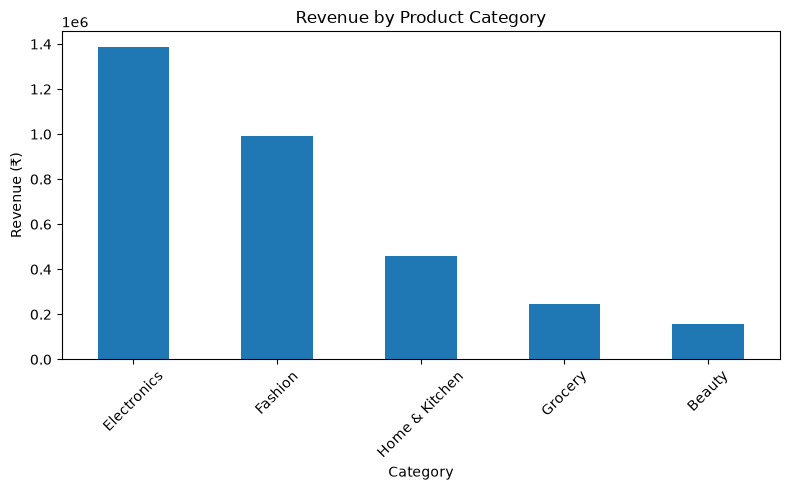

In [56]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("revenue_by_category.png", dpi=300)
plt.show()

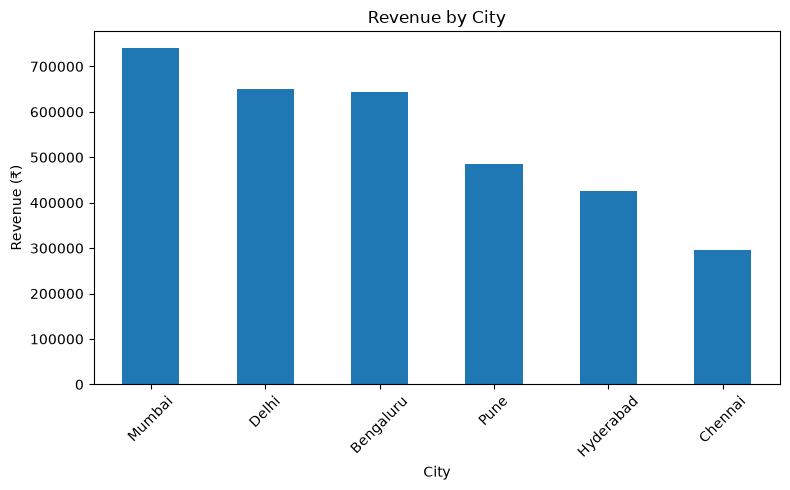

In [57]:
plt.figure(figsize=(8, 5))

city_revenue.plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("revenue_by_city.png", dpi=300)
plt.show()

In [48]:
day_sales = (
    clean_df.groupby("day_type")
    .agg(
        total_revenue=("revenue", "sum"),
        average_order_value=("revenue", "mean"),
        orders=("order_id", "count")
    )
)

day_sales

,total_revenue,average_order_value,orders
day_type,,,
Weekday,2117004.650,1673.521462,1265
Weekend,1125027.578,2102.855286,535


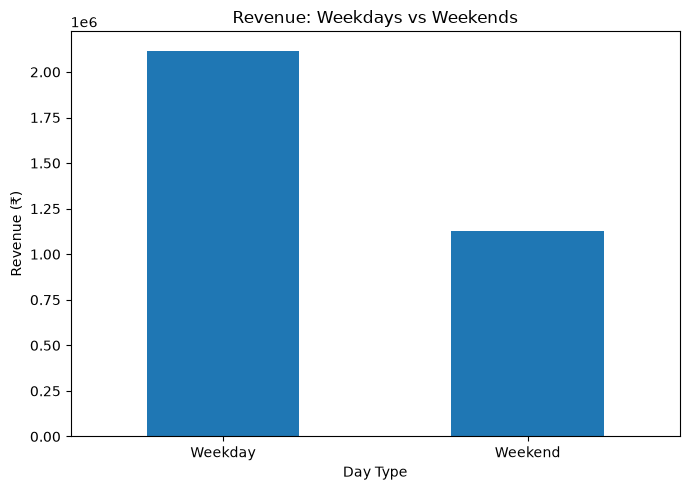

In [58]:
plt.figure(figsize=(7, 5))

day_sales["total_revenue"].plot(kind="bar")

plt.title("Revenue: Weekdays vs Weekends")
plt.xlabel("Day Type")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("weekday_vs_weekend.png", dpi=300)
plt.show()

In [51]:
discount_analysis = (
    clean_df.groupby("discount_pct")["quantity"]
    .agg(["count", "mean", "median", "sum"])
)

print("Quantity sold by discount level:")
display(discount_analysis)

correlation = clean_df["discount_pct"].corr(clean_df["quantity"])

print("\nCorrelation between discount and quantity:", round(correlation, 4))

Quantity sold by discount level:


,count,mean,median,sum
discount_pct,,,,
0.0,1027,1.982473,2.0,2036.0
5.0,249,1.947791,2.0,485.0
10.0,202,2.089109,2.0,422.0
15.0,128,1.726562,1.0,221.0
20.0,116,2.094828,2.0,243.0
25.0,78,2.025641,2.0,158.0



Correlation between discount and quantity: 0.0028


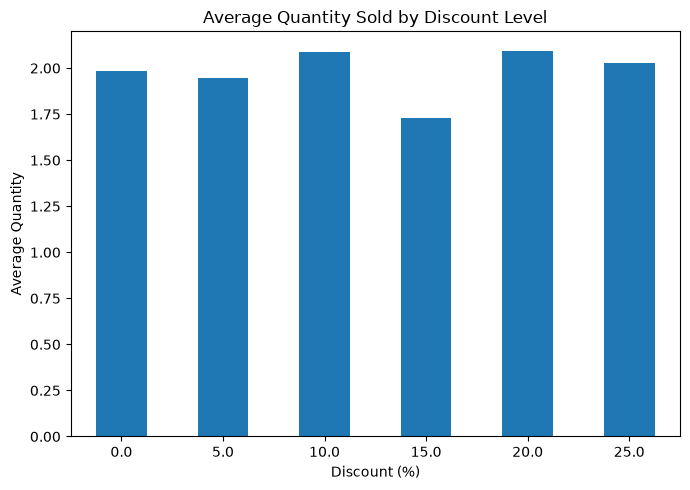

In [59]:
plt.figure(figsize=(7, 5))

discount_analysis["mean"].plot(kind="bar")

plt.title("Average Quantity Sold by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Average Quantity")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("discount_vs_quantity.png", dpi=300)
plt.show()

In [53]:
payment_analysis = (
    clean_df.groupby("payment_method")
    .agg(
        total_revenue=("revenue", "sum"),
        orders=("order_id", "count"),
        average_order_value=("revenue", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

payment_analysis

,total_revenue,orders,average_order_value
payment_method,,,
UPI,1.292150e+06,731,1767.647392
Credit Card,7.175954e+05,399,1798.484690
Debit Card,5.781812e+05,328,1762.747437
Net Banking,3.189449e+05,164,1944.785905
Cash on Delivery,2.920473e+05,151,1934.088050
Unknown,4.311325e+04,27,1596.787019


In [54]:
product_revenue = (
    clean_df.groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

product_name
Smart Watch          542906.6360
Running Shoes        338236.2410
Wireless Earbuds     311465.4895
Bluetooth Speaker    305806.0105
Denim Jacket         249709.7540
Power Bank           174905.1650
Backpack             173080.6875
Electric Kettle      153213.0105
Sunglasses           145667.0730
Non-stick Pan         99046.2360
Name: revenue, dtype: float64

## Additional Insight
Smart Watch is the highest-revenue individual product, generating substantially more revenue than the next-highest product.

In [55]:
rating_analysis = (
    clean_df.groupby("customer_rating", dropna=False)["revenue"]
    .agg(["count", "mean", "sum"])
)

rating_analysis

,count,mean,sum
customer_rating,,,
1.0,62,1552.631258,96263.1380
2.0,107,1707.981762,182754.0485
3.0,272,1901.617357,517239.9210
4.0,478,1827.067647,873338.3355
5.0,361,1778.841557,642161.8020
NaN,520,1788.990352,930274.9830


## Key Findings
- Mumbai generated the highest revenue among the cities.
- Electronics was the highest-revenue product category.
- Weekdays generated more total revenue, while weekends had a higher average order value.
- Discount percentage showed almost no relationship with quantity sold (correlation ≈ 0.003).
- Smart Watch was the highest-revenue individual product.

In [60]:
pd.read_csv(r"C:\Users\asgaj\retailpulse_orders_cleaned.csv").shape

(1800, 13)

In [61]:
clean_df["revenue"].sum()

np.float64(3242032.228)